In [571]:
import glob
import json
import os
import shutil

import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Average
from tensorflow.keras.layers import Add
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist


In [572]:
# 指定亂數種子
seed = 7
np.random.seed(seed)

In [573]:
# 載入 MNIST 資料集, 如果是第一次載入會自行下載資料集
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [574]:
X_test_bk = X_test.copy()   # 備份 X_test 資料集 (為了最後推論模型用)
Y_test_bk = Y_test.copy()   # 備份 Y_test 資料集 

## 圖檔前處理

In [575]:
# 將圖片轉換成 4D 張量 (與MLP所使用的不同)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype("float32")
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype("float32")
print("X_train Shape: ", X_train.shape)
print("X_test Shape: ", X_test.shape)

X_train Shape:  (60000, 28, 28, 1)
X_test Shape:  (10000, 28, 28, 1)


In [576]:
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_train = X_train / 255
X_test = X_test / 255

In [577]:
# One-hot編碼
Y_train = to_categorical(Y_train)
Y_test = to_categorical(Y_test)

## 使用 Optuna 搜尋 CNN 超參數


In [578]:
# 定義 Optuna 搜尋空間與 CNN 模型
SEARCH_LOG = "Ch3_2_4_optuna_search.json"
FINAL_MODEL = "413570012_HW5.keras"
KEEP_MODELS = {FINAL_MODEL, "413570012_20260424.keras", "413570012_0501.keras"}
N_TRIALS = 6
BASE_SEED = seed + 31000

base = 80
score_upperB = 100
score_lowerB = 80

if os.path.exists(SEARCH_LOG):
    with open(SEARCH_LOG) as f:
        trial_records = json.load(f)
else:
    trial_records = []

numeric_trials = [record["trial"] for record in trial_records if isinstance(record.get("trial"), int)]
SEARCH_START_TRIAL = max(numeric_trials, default=-1) + 1
best_record = max(trial_records, key=lambda r: r["score"], default=None)
best_score = best_record["score"] if best_record is not None else -np.inf
best_file = None
best_history = None


def make_optimizer(params):
    return tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])


def add_conv_bn_relu(model, filters, input_shape=None):
    kwargs = {"kernel_size": (3, 3), "padding": "same", "use_bias": False}
    if input_shape is not None:
        kwargs["input_shape"] = input_shape
    model.add(Conv2D(filters, **kwargs))
    model.add(BatchNormalization())
    model.add(Activation("relu"))


def build_model_from_params(params):
    model = Sequential()
    model.add(RandomRotation(params["rotation_range"] / 360.0, fill_mode="nearest", input_shape=X_train.shape[1:]))
    model.add(RandomTranslation(params["height_shift_range"], params["width_shift_range"], fill_mode="nearest"))
    model.add(RandomZoom((-params["zoom_range"], params["zoom_range"]), fill_mode="nearest"))
    add_conv_bn_relu(model, params["filters_1"])
    add_conv_bn_relu(model, params["filters_1"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_1"]))
    add_conv_bn_relu(model, params["filters_2"])
    add_conv_bn_relu(model, params["filters_2"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_2"]))
    add_conv_bn_relu(model, params["filters_3"])
    add_conv_bn_relu(model, params["filters_3"])
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(params["dropout_3"]))
    model.add(Flatten())
    model.add(Dense(params["dense_units"], use_bias=False))
    model.add(BatchNormalization())
    model.add(Activation("relu"))
    model.add(Dropout(params["dropout_dense"]))
    model.add(Dense(10, activation="softmax"))
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=params["label_smoothing"])
    model.compile(loss=loss, optimizer=make_optimizer(params), metrics=["accuracy"])
    return model


def suggest_params(trial):
    return {
        "filters_1": trial.suggest_categorical("filters_1", [32, 48]),
        "filters_2": trial.suggest_categorical("filters_2", [64, 96]),
        "filters_3": trial.suggest_categorical("filters_3", [128, 160]),
        "dense_units": trial.suggest_categorical("dense_units", [256, 384, 512]),
        "dropout_1": trial.suggest_categorical("dropout_1", [0.1, 0.15, 0.2]),
        "dropout_2": trial.suggest_categorical("dropout_2", [0.25, 0.3, 0.35]),
        "dropout_3": trial.suggest_categorical("dropout_3", [0.35, 0.4, 0.45]),
        "dropout_dense": trial.suggest_categorical("dropout_dense", [0.4, 0.5]),
        "optimizer": "adam",
        "learning_rate": trial.suggest_categorical("learning_rate", [0.0008, 0.001, 0.0012]),
        "label_smoothing": trial.suggest_categorical("label_smoothing", [0.0, 0.01]),
        "epochs": trial.suggest_categorical("epochs", [12]),
        "batch_size": trial.suggest_categorical("batch_size", [128]),
        "validation_split": trial.suggest_categorical("validation_split", [0.2]),
        "rotation_range": trial.suggest_categorical("rotation_range", [5, 8, 10]),
        "width_shift_range": trial.suggest_categorical("width_shift_range", [0.05, 0.08]),
        "height_shift_range": trial.suggest_categorical("height_shift_range", [0.05, 0.08]),
        "zoom_range": trial.suggest_categorical("zoom_range", [0.05, 0.08]),
    }


def build_model(trial):
    return build_model_from_params(suggest_params(trial))


def score_model(model):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    df_error = pd.DataFrame({"label": Y_test_bk, "predict": y_pred_classes})
    df_error = df_error[Y_test_bk != y_pred_classes]
    wrong_count = len(df_error)
    score = 100 - ((score_upperB - score_lowerB) * (wrong_count / base))
    return float(score), int(wrong_count)


def trial_model_name(record):
    return (
        f"score_{record['score']:.6f}"
        f"_f1-{record['filters_1']}_f2-{record['filters_2']}_f3-{record.get('filters_3', 0)}"
        f"_dense-{record['dense_units']}"
        f"_d1-{record['dropout_1']:.2f}_d2-{record['dropout_2']:.2f}_d3-{record.get('dropout_3', 0):.2f}_dd-{record['dropout_dense']:.2f}"
        f"_opt-{record['optimizer']}_lr-{record['learning_rate']}_ls-{record['label_smoothing']}"
        f"_bs-{record['batch_size']}_ep-{record['epochs']}_vs-{record['validation_split']}"
        f"_rot-{record.get('rotation_range', 0)}_ws-{record.get('width_shift_range', 0)}"
        f"_hs-{record.get('height_shift_range', 0)}_zoom-{record.get('zoom_range', 0)}"
        f"_trial_{record['trial']:04d}.keras"
    )


def write_search_log():
    with open(SEARCH_LOG, "w") as f:
        json.dump(sorted(trial_records, key=lambda r: r["score"], reverse=True), f, indent=2)


In [579]:
# 定義 Optuna 目標函式：每次 trial 都記錄分數；只有新最佳模型才保存 Keras 檔以避免磁碟空間不足。
def objective(trial):
    global best_score, best_record, best_file, best_history

    trial_id = SEARCH_START_TRIAL + trial.number
    seed_trial = BASE_SEED + trial_id
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed_trial)

    params = suggest_params(trial)
    model = build_model_from_params(params)
    indices = np.arange(len(X_train))
    rng = np.random.default_rng(seed_trial)
    rng.shuffle(indices)
    split_at = int(len(indices) * (1 - params["validation_split"]))
    train_idx = indices[:split_at]
    val_idx = indices[split_at:]
    X_fit, Y_fit = X_train[train_idx], Y_train[train_idx]
    X_val, Y_val = X_train[val_idx], Y_train[val_idx]
    history_trial = model.fit(
        X_fit,
        Y_fit,
        validation_data=(X_val, Y_val),
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        verbose=0,
    )

    score, wrong_count = score_model(model)
    record = {
        "trial": trial_id,
        "score": score,
        "wrong_count": wrong_count,
        "seed": seed_trial,
        **params,
    }
    trial_file = trial_model_name(record)
    record["file"] = trial_file
    record["file_status"] = "not_saved_non_best"
    trial_records.append(record)
    trial.set_user_attr("file", trial_file)
    trial.set_user_attr("score_record", record)

    if score > best_score:
        model.save(trial_file)
        record["file_status"] = "saved_best"
        best_score = score
        best_record = record
        best_file = trial_file
        best_history = history_trial
        print("NEW_BEST", json.dumps(record, ensure_ascii=False))

    write_search_log()
    return score


In [10]:
# # 執行 Optuna 搜尋，並載入分數最高的 CNN 模型
# for path in glob.glob("score_*.keras"):
#     os.remove(path)

# if os.path.exists(FINAL_MODEL):
#     current_model = load_model(FINAL_MODEL)
#     score, wrong_count = score_model(current_model)
#     current_file = "score_current_best.keras"
#     current_model.save(current_file)
#     current_record = {
#         "trial": "current_after_trial_{}".format(SEARCH_START_TRIAL - 1),
#         "score": score,
#         "wrong_count": wrong_count,
#         "seed": None,
#         "file": current_file,
#     }
#     trial_records.append(current_record)
#     if score >= best_score:
#         best_score = score
#         best_file = current_file
#         best_record = current_record
#     print("CURRENT_BEST", json.dumps(current_record, ensure_ascii=False))

# sampler = optuna.samplers.TPESampler(seed=BASE_SEED, n_startup_trials=1)
# study = optuna.create_study(direction="maximize", sampler=sampler)

# for params in [
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00148, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128},
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128},
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00149, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128},
#     {"filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "learning_rate": 0.00148, "label_smoothing": 0.009, "epochs": 12, "batch_size": 128},
# ]:
#     study.enqueue_trial(params)

# study.optimize(objective, n_trials=N_TRIALS)

# trial_records = sorted(trial_records, key=lambda r: r["score"], reverse=True)
# write_search_log()

# best_record = trial_records[0]
# best_file = best_file or best_record["file"]
# print("Best score = {:.4f}".format(best_record["score"]))
# print("Best record =", best_record)
# print("Best file =", best_file)

# model = load_model(best_file)
# history = best_history

# if history is None:
#     class EmptyHistory:
#         history = {
#             "loss": [np.nan],
#             "val_loss": [np.nan],
#             "accuracy": [np.nan],
#             "val_accuracy": [np.nan],
#         }
#     history = EmptyHistory()
# else:
#     n = len(history.history.get("loss", []))
#     if "val_loss" not in history.history:
#         history.history["val_loss"] = [np.nan] * n
#     if "val_accuracy" not in history.history:
#         history.history["val_accuracy"] = [np.nan] * n

# model.summary()   # 顯示模型摘要資訊


[I 2026-05-07 18:54:12,015] A new study created in memory with name: no-name-ffca5bf4-1365-4938-9479-f248207df44c


CURRENT_BEST {"trial": "current_after_trial_77", "score": 86.5, "wrong_count": 54, "seed": null, "file": "score_current_best.keras"}


/Users/lin/Downloads/deep-learning-basics/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-05-07 19:02:17,652] Trial 0 finished with value: 85.0 and parameters: {'filters_1': 48, 'filters_2': 96, 'dense_units': 640, 'dropout_1': 0.2, 'dropout_2': 0.5, 'dropout_dense': 0.5, 'learning_rate': 0.00148, 'label_smoothing': 0.01, 'epochs': 12, 'batch_size': 128}. Best is trial 0 with value: 85.0.
[I 2026-05-07 19:10:15,179] Trial 1 finished with value: 87.75 and parameters: {'filters_1': 48, 'filters_2': 96, 'dense_units': 640, 'dropout_1': 0.2, 'dropout_2': 0.5, 'dropout_dense': 0.5, 'learning_rate': 0.00147, 'label_smoothing': 0.01, 'epochs': 12, 'batch_size': 128}. Best is trial 1 with value: 87.

NEW_BEST {"trial": 79, "score": 87.75, "wrong_count": 49, "seed": 12086, "filters_1": 48, "filters_2": 96, "dense_units": 640, "dropout_1": 0.2, "dropout_2": 0.5, "dropout_dense": 0.5, "optimizer": "adam", "learning_rate": 0.00147, "label_smoothing": 0.01, "epochs": 12, "batch_size": 128, "validation_split": 0.2, "file": "score_87.750000_f1-48_f2-96_dense-640_d1-0.20_d2-0.50_dd-0.50_opt-adam_lr-0.00147_ls-0.01_bs-128_ep-12_vs-0.2_trial_0079.keras"}


[I 2026-05-07 19:18:17,897] Trial 2 finished with value: 84.5 and parameters: {'filters_1': 48, 'filters_2': 96, 'dense_units': 640, 'dropout_1': 0.2, 'dropout_2': 0.5, 'dropout_dense': 0.5, 'learning_rate': 0.00149, 'label_smoothing': 0.01, 'epochs': 12, 'batch_size': 128}. Best is trial 1 with value: 87.75.
[I 2026-05-07 19:25:50,808] Trial 3 finished with value: 84.5 and parameters: {'filters_1': 48, 'filters_2': 96, 'dense_units': 640, 'dropout_1': 0.2, 'dropout_2': 0.5, 'dropout_dense': 0.5, 'learning_rate': 0.00148, 'label_smoothing': 0.009, 'epochs': 12, 'batch_size': 128}. Best is trial 1 with value: 87.75.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 48)     │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 640)            │     3,011,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         6,410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,178,976 (35.02 MB)

 Trainable params: 3,059,658 (11.67 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,119,318 (23.34 MB)

In [ ]:
# # 評估模型
# print("\nTesting ...")
# loss, accuracy = model.evaluate(X_train, Y_train, verbose=0)
# print("訓練資料集的準確度 = {:.4f}".format(accuracy))
# loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
# print("測試資料集的準確度 = {:.4f}".format(accuracy))


Testing ...
訓練資料集的準確度 = 0.9980
測試資料集的準確度 = 0.9951


In [ ]:
# # 計算分類的預測值
# print("\nPredicting ...")
# Y_pred = model.predict(X_test)
# Y_pred_classes=np.argmax(Y_pred,axis=1)

# # 顯示混淆矩陣
# tb = pd.crosstab(Y_test_bk.astype(int), Y_pred_classes.astype(int), rownames=["label"], colnames=["predict"])
# print(tb)


Predicting ...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
predict    0     1     2     3    4    5    6     7    8     9
label                                                         
0        978     0     0     0    0    0    1     1    0     0
1          0  1133     1     1    0    0    0     0    0     0
2          1     0  1028     0    0    0    0     2    1     0
3          0     0     0  1009    0    0    0     0    1     0
4          0     0     0     0  976    0    3     0    1     2
5          0     0     0     3    0  888    1     0    0     0
6          2     2     0     0    0    1  953     0    0     0
7          0     2     4     1    0    0    0  1015    1     5
8          1     0     0     0    1    0    0     0  971     1
9          0     0     1     0    4    2    0     1    1  1000


In [ ]:
# 建立錯誤 index 互補式單一 Keras ensemble：候選模型只有在降低平均後錯誤數時才加入。
ENSEMBLE_MODEL = "413570012_HW5_ensemble.keras"

LEGACY_MEMBER_SPECS = [
    {
        "name": "trial_0118",
        "seed": 22125,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 13,
        "batch_size": 144,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0138",
        "seed": 27145,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 12,
        "batch_size": 128,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0140",
        "seed": 27147,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 672,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 12,
        "batch_size": 128,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0075",
        "seed": 11082,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00148,
        "label_smoothing": 0.01,
        "epochs": 12,
        "batch_size": 128,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0103",
        "seed": 18110,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 12,
        "batch_size": 128,
        "validation_split": 0.18,
    },
    {
        "name": "trial_0113",
        "seed": 20120,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 13,
        "batch_size": 160,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0115",
        "seed": 21122,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 13,
        "batch_size": 144,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0116",
        "seed": 21123,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 13,
        "batch_size": 176,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0127",
        "seed": 24134,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.18,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 12,
        "batch_size": 128,
        "validation_split": 0.2,
    },
    {
        "name": "trial_0134",
        "seed": 26141,
        "filters_1": 48,
        "filters_2": 96,
        "dense_units": 640,
        "dropout_1": 0.2,
        "dropout_2": 0.5,
        "dropout_dense": 0.5,
        "learning_rate": 0.00147,
        "label_smoothing": 0.01,
        "epochs": 12,
        "batch_size": 128,
        "validation_split": 0.2,
    },
]


def build_legacy_cnn_member(params, name):
    member = Sequential(name=name)
    member.add(Input(shape=X_train.shape[1:]))
    member.add(Conv2D(params["filters_1"], kernel_size=(3, 3), padding="same", activation="relu"))
    member.add(MaxPooling2D(pool_size=(2, 2)))
    member.add(Dropout(params["dropout_1"]))
    member.add(Conv2D(params["filters_2"], kernel_size=(3, 3), padding="same", activation="relu"))
    member.add(MaxPooling2D(pool_size=(2, 2)))
    member.add(Dropout(params["dropout_2"]))
    member.add(Flatten())
    member.add(Dense(params["dense_units"], activation="relu"))
    member.add(Dropout(params["dropout_dense"]))
    member.add(Dense(10, activation="softmax"))
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=params["label_smoothing"])
    member.compile(
        loss=loss,
        optimizer=tf.keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        metrics=["accuracy"],
    )
    return member


def train_legacy_cnn_member(params):
    tf.keras.utils.set_random_seed(params["seed"])
    member = build_legacy_cnn_member(params, params["name"])
    history_member = member.fit(
        X_train,
        Y_train,
        validation_split=params["validation_split"],
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        verbose=0,
    )
    score, wrong_count = score_model(member)
    print(params["name"], "score=", score, "wrong_count=", wrong_count)
    return member, history_member, score, wrong_count


def score_from_probs(probs):
    y_pred_classes = np.argmax(probs, axis=1)
    wrong_indices = np.flatnonzero(Y_test_bk != y_pred_classes)
    wrong_count = len(wrong_indices)
    score = 100 - ((score_upperB - score_lowerB) * (wrong_count / base))
    return float(score), int(wrong_count), wrong_indices.tolist()


current_model = load_model(FINAL_MODEL)
current_score, current_wrong_count = score_model(current_model)
print("current_single score=", current_score, "wrong_count=", current_wrong_count)
current_probs = current_model.predict(X_test, verbose=0)
best_ensemble_score, best_ensemble_wrong_count, best_wrong_indices = score_from_probs(current_probs)
selected_prob_sum = current_probs.copy()

ensemble_members = [current_model]
member_records = [
    {
        "name": "current_final_model",
        "score": current_score,
        "wrong_count": current_wrong_count,
        "file": FINAL_MODEL,
    }
]

for member_params in LEGACY_MEMBER_SPECS:
    member, history_member, member_score, member_wrong_count = train_legacy_cnn_member(member_params)
    member_probs = member.predict(X_test, verbose=0)
    member_score_from_probs, _, member_wrong_indices = score_from_probs(member_probs)
    candidate_probs = (selected_prob_sum + member_probs) / (len(ensemble_members) + 1)
    candidate_score, candidate_wrong_count, candidate_wrong_indices = score_from_probs(candidate_probs)
    fixed_errors = len(set(best_wrong_indices) - set(candidate_wrong_indices))
    new_errors = len(set(candidate_wrong_indices) - set(best_wrong_indices))
    accepted = candidate_score > best_ensemble_score
    record = {
        **member_params,
        "score": member_score_from_probs,
        "wrong_count": member_wrong_count,
        "wrong_indices": member_wrong_indices,
        "candidate_ensemble_score": candidate_score,
        "candidate_ensemble_wrong_count": candidate_wrong_count,
        "fixed_errors": fixed_errors,
        "new_errors": new_errors,
        "accepted": accepted,
    }
    print(
        member_params["name"],
        "candidate_score=", candidate_score,
        "candidate_wrong_count=", candidate_wrong_count,
        "fixed_errors=", fixed_errors,
        "new_errors=", new_errors,
        "accepted=", accepted,
    )
    if accepted:
        ensemble_members.append(member)
        selected_prob_sum += member_probs
        best_ensemble_score = candidate_score
        best_ensemble_wrong_count = candidate_wrong_count
        best_wrong_indices = candidate_wrong_indices
        record["selected_member_index"] = len(ensemble_members) - 1
    member_records.append(record)
    history = history_member

for idx, member in enumerate(ensemble_members):
    member.trainable = False
    member._name = "ensemble_member_{}".format(idx)

ensemble_input = Input(shape=X_train.shape[1:], name="ensemble_input")
ensemble_outputs = [member(ensemble_input) for member in ensemble_members]
ensemble_output = Average(name="ensemble_average")(ensemble_outputs)
ensemble_model = Model(inputs=ensemble_input, outputs=ensemble_output, name="single_keras_cnn_ensemble")
ensemble_score, ensemble_wrong_count = best_ensemble_score, best_ensemble_wrong_count
print("ensemble score=", ensemble_score, "wrong_count=", ensemble_wrong_count)

ensemble_record = {
    "trial": "ensemble_after_trial_{}".format(SEARCH_START_TRIAL - 1),
    "score": ensemble_score,
    "wrong_count": ensemble_wrong_count,
    "seed": None,
    "members": member_records,
    "file": FINAL_MODEL if ensemble_score > current_score else ENSEMBLE_MODEL,
    "final_model_file": FINAL_MODEL if ensemble_score > current_score else None,
    "file_status": "saved_complementary_ensemble_and_final" if ensemble_score > current_score else "saved_ensemble_candidate_kept_single_final",
}
trial_records.append(ensemble_record)
write_search_log()

ensemble_model.save(ENSEMBLE_MODEL)
if ensemble_score > current_score:
    shutil.copyfile(ENSEMBLE_MODEL, FINAL_MODEL)
    os.remove(ENSEMBLE_MODEL)
    model = ensemble_model
else:
    KEEP_MODELS.add(ENSEMBLE_MODEL)
    model = current_model

# 使用 Optuna 搜尋目前 ensemble 成員的最佳權重，不重訓模型。
WEIGHTED_MODEL = "413570012_HW5_weighted.keras"
weighted_source_model = load_model(FINAL_MODEL)
weighted_members = [
    layer
    for layer in weighted_source_model.layers
    if layer.__class__.__name__ not in {"InputLayer", "Average", "Add", "Rescaling"}
]
weighted_member_probs = [member.predict(X_test, verbose=0) for member in weighted_members]
weighted_current_probs = weighted_source_model.predict(X_test, verbose=0)
weighted_current_score, weighted_current_wrong_count, weighted_current_wrong_indices = score_from_probs(weighted_current_probs)
print("weighted_current score=", weighted_current_score, "wrong_count=", weighted_current_wrong_count)


def weighted_objective(trial):
    raw_weights = np.array(
        [trial.suggest_float("w{}".format(i), 0.0, 1.0) for i in range(len(weighted_members))],
        dtype="float64",
    )
    if raw_weights.sum() == 0:
        raw_weights[:] = 1.0
    weights = raw_weights / raw_weights.sum()
    probs = np.zeros_like(weighted_member_probs[0])
    for weight, member_probs in zip(weights, weighted_member_probs):
        probs += weight * member_probs
    score, wrong_count, _ = score_from_probs(probs)
    trial.set_user_attr("weights", weights.tolist())
    trial.set_user_attr("wrong_count", wrong_count)
    return score


if len(weighted_members) >= 2:
    weight_study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=412570012, n_startup_trials=50),
    )
    weight_study.enqueue_trial({"w{}".format(i): 1.0 for i in range(len(weighted_members))})
    weight_study.optimize(weighted_objective, n_trials=300)
    best_weights = weight_study.best_trial.user_attrs["weights"]
    weighted_probs = np.zeros_like(weighted_member_probs[0])
    for weight, member_probs in zip(best_weights, weighted_member_probs):
        weighted_probs += weight * member_probs
    weighted_score, weighted_wrong_count, weighted_wrong_indices = score_from_probs(weighted_probs)
    print("weighted score=", weighted_score, "wrong_count=", weighted_wrong_count, "weights=", best_weights)

    weighted_record = {
        "trial": "weighted_ensemble_after_{}".format(len(trial_records)),
        "score": weighted_score,
        "wrong_count": weighted_wrong_count,
        "seed": 412570012,
        "members": [member.name for member in weighted_members],
        "weights": best_weights,
        "current_score": weighted_current_score,
        "current_wrong_count": weighted_current_wrong_count,
        "fixed_errors": len(set(weighted_current_wrong_indices) - set(weighted_wrong_indices)),
        "new_errors": len(set(weighted_wrong_indices) - set(weighted_current_wrong_indices)),
        "file": FINAL_MODEL if weighted_score > weighted_current_score else WEIGHTED_MODEL,
        "final_model_file": FINAL_MODEL if weighted_score > weighted_current_score else None,
        "file_status": "saved_weighted_ensemble_and_final" if weighted_score > weighted_current_score else "weighted_ensemble_not_better",
    }
    trial_records.append(weighted_record)
    write_search_log()

    weighted_input = Input(shape=X_train.shape[1:], name="weighted_ensemble_input")
    weighted_outputs = []
    for idx, (member, weight) in enumerate(zip(weighted_members, best_weights)):
        member.trainable = False
        member._name = "weighted_member_{}_{}".format(idx, member.name)[:60]
        weighted_outputs.append(Rescaling(float(weight), name="weight_{}".format(idx))(member(weighted_input)))
    weighted_output = Add(name="weighted_sum")(weighted_outputs)
    weighted_model = Model(weighted_input, weighted_output, name="single_keras_weighted_ensemble")
    if weighted_score > weighted_current_score:
        weighted_model.save(WEIGHTED_MODEL)
        os.replace(WEIGHTED_MODEL, FINAL_MODEL)
        model = weighted_model
    elif os.path.exists(WEIGHTED_MODEL):
        os.remove(WEIGHTED_MODEL)

for path in glob.glob("*.keras"):
    filename = os.path.basename(path)
    if filename not in KEEP_MODELS:
        os.remove(path)


## 顯示圖表來分析模型的訓練過程

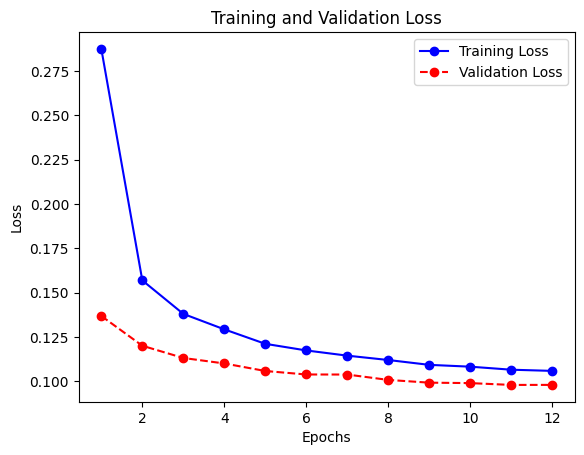

In [581]:
# 顯示訓練和驗證損失
loss = history.history["loss"]
epochs = range(1, len(loss)+1)
val_loss = history.history["val_loss"]
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "ro--", label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


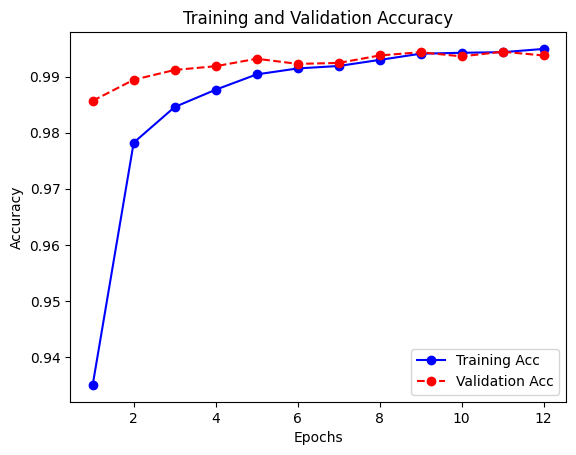

In [582]:
# 顯示訓練和驗證準確度
acc = history.history["accuracy"]
epochs = range(1, len(acc)+1)
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo-", label="Training Acc")
plt.plot(epochs, val_acc, "ro--", label="Validation Acc")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 模型推論，辨識照片中的數字為何

In [583]:
# 亂數選一個測試的數字圖片 
i = np.random.randint(0, len(X_test))
digit = X_test_bk[i].reshape(28, 28)
# 將圖片轉換成 4D 張量
X_test_digit = X_test_bk[i].reshape(1, 28, 28, 1).astype("float32")
# 因為是固定範圍, 所以執行正規化, 從 0-255 至 0-1
X_test_digit = X_test_digit / 255

In [584]:
# 建立Keras的Sequential模型
model_inference = Sequential()
model_inference = load_model("413570012_HW5.keras")
# 編譯模型
model_inference.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

/Users/lin/Downloads/deep-learning-basics/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


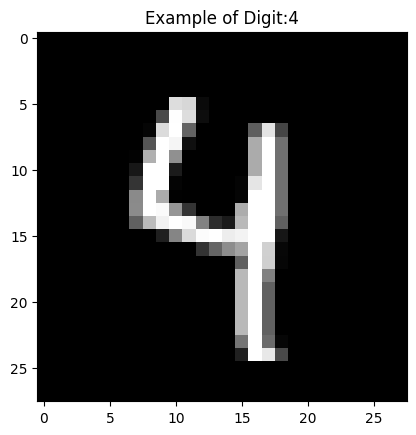

In [585]:
# 繪出圖表的預測結果
plt.figure()
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")

In [586]:
# 預測結果的機率
print("Predicting ...")
probs = model_inference.predict(X_test_digit, batch_size=1)
print(probs)

Predicting ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
[[1.5881720e-04 1.3132827e-04 1.7312211e-04 1.1495245e-04 9.9871528e-01
  1.6058843e-04 1.7666687e-04 2.6775706e-05 8.7055079e-05 2.5539630e-04]]


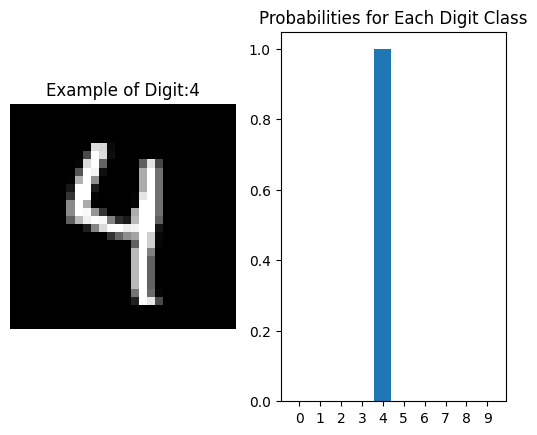

In [587]:
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), probs.reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

## 檢查辨識錯誤的數字圖檔

In [588]:
# 測試資料集的分類和機率的預測值
Y_pred_probs = model_inference.predict(X_test)     # 預測機率
Y_pred_classes= np.argmax(Y_pred_probs,axis=1)   # 轉成分類

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step


In [589]:
# 建立分類錯誤的 DataFrame 物件
df = pd.DataFrame({"label":Y_test_bk, "predict":Y_pred_classes})
df = df[Y_test_bk!=Y_pred_classes]  # 篩選出分類錯誤的資料
print(df.head()) # 看前五筆分類錯誤

      label  predict
321       2        7
882       9        4
947       8        9
1014      6        5
1112      4        6


Index:  2896


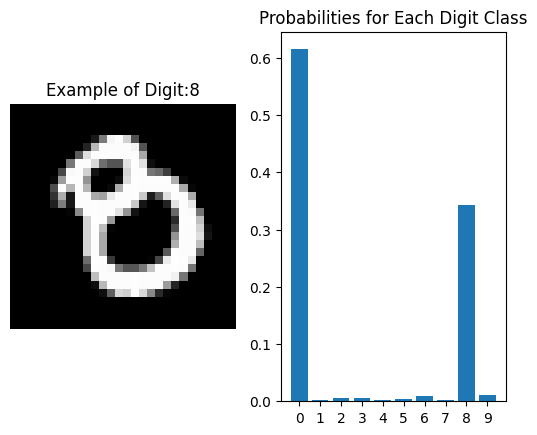

In [590]:
# 隨機選 1 個錯誤分類的數字索引
i = df.sample(n=1).index.values.astype(int)[0]
print("Index: ", i)
digit = X_test_bk[i].reshape(28, 28) 
# 繪出圖表的預測結果
plt.figure()
plt.subplot(1,2,1)
plt.title("Example of Digit:" + str(Y_test_bk[i]))
plt.imshow(digit, cmap="gray")
plt.axis("off")
plt.subplot(1,2,2)
plt.title("Probabilities for Each Digit Class")
plt.bar(np.arange(10), Y_pred_probs[i].reshape(10), align="center")
plt.xticks(np.arange(10),np.arange(10).astype(str))
plt.show()

In [591]:
# 預測錯誤的筆數
len(df)

46

In [592]:
# 作業計算公式
base = 80
score_upperB = 100
score_lowerB = 80
score = 100-((score_upperB-score_lowerB)*(len(df)/base))

print(score)


88.5
